# MatrixDesing

В этом ноутбуке я построю матрицу взаимодействия и протестирую AILS модель.

## Импорт библиоткек

In [18]:
import pandas as pd
import numpy as np
import implicit
import os
from scipy import sparse
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path

## Загрузка данных

In [2]:
BASE_PATH = os.path.abspath("../../../Tables/CleanTable")

In [3]:
users_clean = pd.read_csv(os.path.join(BASE_PATH, 'users_clean_final.csv'), encoding='utf-8')
items_clean = pd.read_csv(os.path.join(BASE_PATH, 'items_clean_final.csv'), encoding='utf-8')
user_items = pd.read_csv(os.path.join(BASE_PATH, 'user_items_final.csv'), encoding='utf-8')

## Построение матрицы __User-Item__

Формула для Confidence (weight)

__Weight = 1 + log(N)__, где N - количество посещений

Такая формула была выбрана, потому что она:
1)  Учитывает размерность самых частых услуг (log сгладит услуги с крупными посещениями).
2) Учитывает частоту посещений и поощеряет услугу, если клиент часто на неё ходит.

Тогда матрица будет в формате:

`id_user` | `id_item` | `Weight`

#### Считаем Weight

In [5]:
# 1. Считаем посещения с весами
user_item_matrix = user_items.groupby(['user_id', 'item_id']).size().reset_index(name='N_visits')

# 2. Weight = 1 + log(N)
user_item_matrix['confidence'] = 1 + np.log(user_item_matrix['N_visits'])

#### CSR матрица

In [6]:
rows = user_item_matrix['user_id'].values
cols = user_item_matrix['item_id'].values
data = user_item_matrix['confidence'].values

In [7]:
user_item_sparse = sparse.csr_matrix((data, (rows, cols)),
                                   shape=(users_clean['id_user'].max()+1,
                                          items_clean['id_item'].max()+1))

#### Оценка матрицы

In [15]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
weights = user_item_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
N=1 → вес≥1.00: 970 (100.0%)
N=2 → вес≥1.69: 90 (9.3%)
N=3 → вес≥2.10: 10 (1.0%)
N=4 → вес≥2.39: 2 (0.2%)
N=5 → вес≥2.61: 0 (0.0%)
N=6 → вес≥2.79: 0 (0.0%)
N=7 → вес≥2.95: 0 (0.0%)
N=8 → вес≥3.08: 0 (0.0%)
N=9 → вес≥3.20: 0 (0.0%)
N=10 → вес≥3.30: 0 (0.0%)


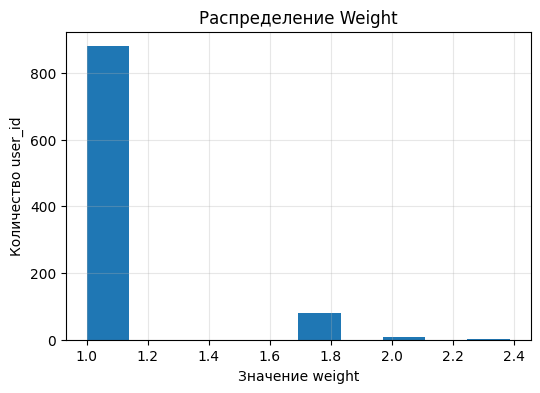

In [9]:
plt.figure(figsize=(6,4))

plt.title('Распределение Weight')
plt.xlabel('Значение weight')
plt.ylabel('Количество user_id')

plt.hist(data)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
print("=== БАЗОВАЯ ИНФОРМАЦИЯ ===")
print(f"Форма матрицы: {user_item_sparse.shape}")
print(f"NNZ (непустых): {user_item_sparse.nnz}")
print(f"Доля заполненности: {user_item_sparse.nnz / (user_item_sparse.shape[0] * user_item_sparse.shape[1]):.4f}")
print(f"Диапазон весов: {user_item_sparse.data.min():.2f} → {user_item_sparse.data.max():.2f}")
print(f"Средний вес: {user_item_sparse.data.mean():.2f}")

=== БАЗОВАЯ ИНФОРМАЦИЯ ===
Форма матрицы: (2893, 258)
NNZ (непустых): 970
Доля заполненности: 0.0013
Диапазон весов: 1.00 → 2.39
Средний вес: 1.07


In [11]:
print("\n=== ПРОВЕРКА ID ===")
print(f"Users: ID 0-{users_clean['id_user'].max()} ({len(users_clean)} активных)")
print(f"Items: ID 0-{items_clean['id_item'].max()} ({len(items_clean)} активных)")
print(f"В матрице: users {user_item_sparse.shape[0]}, items {user_item_sparse.shape[1]} ✓")



=== ПРОВЕРКА ID ===
Users: ID 0-2892 (2711 активных)
Items: ID 0-257 (136 активных)
В матрице: users 2893, items 258 ✓


In [16]:
print("\n=== ТОП-5 ===")
user_sums = np.array(user_item_sparse.sum(axis=1)).flatten()
item_sums = np.array(user_item_sparse.sum(axis=0)).flatten()

print(f"Самый активный user_id: {np.argmax(user_sums)} (вес: {user_sums.max():.1f})")
print(f"Самая популярная услуга item_id: {np.argmax(item_sums)} (вес: {item_sums.max():.1f})")



=== ТОП-5 ===
Самый активный user_id: 2701 (вес: 6.0)
Самая популярная услуга item_id: 22 (вес: 429.7)


#### Сохранение матрицы

In [ ]:
result_path = Path('../../../results/matrices')


In [24]:
sparse.save_npz(result_path / 'artnail_user_item_sparse.npz', user_item_sparse)
print(f"  Путь: {result_path / 'artnail_user_item_sparse.npz'}")
print(f"  Размер: {os.path.getsize(result_path / 'artnail_user_item_sparse.npz') / 1024:.1f} КБ")

  Путь: ..\..\..\results\matrices\artnail_user_item_sparse.npz
  Размер: 3.6 КБ
